In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd 
loan = pd.read_csv("D:\\INTERN-SHIP\\Loan_new.csv",encoding='utf-8')
loan

,loan_id,customer_id,credit_profile_id,loan_amount,interest_rate,tenure_months,emi,disbursal_date,dti_ratio,default_flag,loan_status,total_paid_amount,outstanding_amount,days_past_due
0,20213,1002,5160,279577,9.04,24,12777.53,25-06-2024,0.08,0,Active,117180.53,162396.47,8
1,20182,1003,5156,331696,10.81,12,29286.45,09-04-2022,0.24,1,Default,185288.78,146407.22,167
2,20034,1004,5138,1445796,12.27,24,68241.08,21-08-2022,0.38,1,Default,916245.96,529550.04,172
3,20179,1007,5036,142036,12.10,24,6692.76,25-09-2024,0.04,0,Active,112407.81,29628.19,4
4,20267,1007,5056,939493,15.77,12,85138.78,07-08-2023,0.47,1,Default,698422.23,241070.77,160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,20138,1246,5154,237256,15.54,24,11564.71,03-07-2024,0.66,1,Default,71417.96,165838.04,113
296,20249,1246,5010,180356,13.85,48,4914.93,15-01-2023,0.28,0,Active,139649.43,40706.57,7
297,20046,1248,5203,1252060,16.34,60,30674.32,17-04-2023,0.25,1,Default,494176.07,757883.93,159
298,20289,1248,5084,467567,14.67,60,11042.56,05-06-2024,0.09,0,Active,163456.14,304110.86,9


In [4]:
import pandas as pd 
customer = pd.read_csv("D:\\INTERN-SHIP\\customer_new.csv",encoding='utf-8')
customer

,customer_id,customer_name,age,gender,marital_status,state,employment_type,annual_income,dependents,customer_segment
0,1001,Pranav Joshi,50,Male,Single,Maharashtra,Salaried,1196261,0,Medium
1,1002,Harsh Agarwal,36,Male,Married,Karnataka,Salaried,1905215,1,High
2,1003,Vikram Choudhary,29,Male,Married,Delhi,Salaried,1442845,3,Medium
3,1004,Sneha Yadav,42,Female,Married,Delhi,Salaried,2146504,2,High
4,1005,Karthik Iyer,40,Male,Single,Delhi,Salaried,2435307,3,High
...,...,...,...,...,...,...,...,...,...,...
245,1246,Meera Agarwal,54,Female,Single,Bihar,Salaried,211303,1,Low
246,1247,Vivaan Singh,35,Male,Married,Bihar,Salaried,1410209,2,Medium
247,1248,Diya Verma,42,Female,Single,Delhi,Salaried,1498266,2,Medium
248,1249,Diya Verma,41,Female,Married,Delhi,Salaried,1209612,1,Medium


In [5]:
import pandas as pd 
credit = pd.read_csv("D:\\INTERN-SHIP\\credit_new.csv",encoding='utf-8')
credit

,credit_profile_id,credit_score,total_open_accounts,past_defaults,credit_utilization_ratio,credit_history_years,inquiries_last_6_months,risk_grade
0,5001,310,1,0,0.72,14,4,D
1,5002,600,1,1,0.35,6,1,C
2,5003,401,3,0,0.25,16,4,D
3,5004,724,6,0,0.64,19,5,B
4,5005,691,3,0,0.52,14,2,B
...,...,...,...,...,...,...,...,...
245,5246,364,4,0,0.45,12,0,D
246,5247,375,9,0,0.78,6,0,D
247,5248,442,4,0,0.51,1,5,D
248,5249,772,4,1,0.12,4,4,A


In [6]:
# 1. What is the total number of loans?
len(loan)

300

In [7]:
# 2. How many unique customers are there in the dataset?
loan['customer_id'].nunique()

183

In [8]:
# 3. What is the total loan portfolio size?
loan_amount = loan['loan_amount'].sum()
outstanding_amount = loan['outstanding_amount'].sum()
total_paid_amount = loan['total_paid_amount'].sum()
print(loan_amount, outstanding_amount, total_paid_amount )

224137409 102980916.53 121156492.47


In [9]:
# 4. What is the average loan amount by customer segment?
df =pd.merge(loan,customer,on='customer_id',how='outer')
avg_loan_amount = df.groupby('customer_segment')['loan_amount'].sum()
print(avg_loan_amount)

customer_segment
High      86902681.0
Low       41948649.0
Medium    95286079.0
Name: loan_amount, dtype: float64


In [10]:
# 5. Which state has the highest total loan and highest default?
df = loan.merge(customer,on='customer_id')
state_analysis = df.groupby('state')['loan_amount'].sum()
print('state_analysis:',state_analysis)


state_analysis: state
Bihar             47188455
Delhi             50558872
Karnataka         30928520
Madhya Pradesh    41331270
Maharashtra       54130292
Name: loan_amount, dtype: int64


In [11]:
# 6. What is the distribution of loan amounts?
print(loan['loan_amount'].describe())

count    3.000000e+02
mean     7.471247e+05
std      4.408794e+05
min      6.236000e+04
25%      3.447845e+05
50%      6.982450e+05
75%      1.145701e+06
max      1.499466e+06
Name: loan_amount, dtype: float64


In [12]:
# 7. How many missing values exist in each table?
print("loan_missing_value: ",loan.isnull().sum())
print("credit_missing_value: ",credit.isnull().sum())
print("customer_missing_value: ",customer.isnull().sum())

loan_missing_value:  loan_id               0
customer_id           0
credit_profile_id     0
loan_amount           0
interest_rate         0
tenure_months         0
emi                   0
disbursal_date        0
dti_ratio             0
default_flag          0
loan_status           0
total_paid_amount     0
outstanding_amount    0
days_past_due         0
dtype: int64
credit_missing_value:  credit_profile_id           0
credit_score                0
total_open_accounts         0
past_defaults               0
credit_utilization_ratio    0
credit_history_years        0
inquiries_last_6_months     0
risk_grade                  0
dtype: int64
customer_missing_value:  customer_id         0
customer_name       0
age                 0
gender              0
marital_status      0
state               0
employment_type     0
annual_income       0
dependents          0
customer_segment    0
dtype: int64


In [13]:
# 8. What is the average days past due by risk grade?
df = loan.merge(credit, on='credit_profile_id')

days_past_due = df.groupby('risk_grade')['days_past_due'].mean()
print(days_past_due)


risk_grade
A     34.775000
B     32.727273
C     50.666667
D    105.558824
Name: days_past_due, dtype: float64


In [14]:
# 9. Calculate mean, median, std deviation of loan amounts using NumPy.
loan_mean = np.mean(loan['loan_amount'])
loan_median = np.median(loan['loan_amount'])
loan_std = np.std(loan['loan_amount'])
print(loan_mean, loan_median, loan_std)

747124.6966666667 698245.0 440143.98004522495


Text(0, 0.5, 'LOAN AMOUNTS')

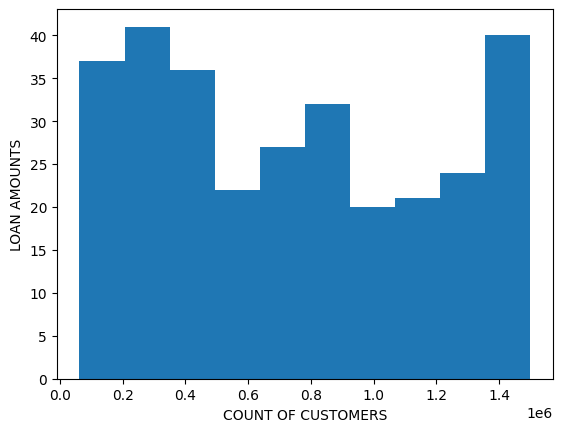

In [15]:
# 10. Plot distribution of loan amounts (histogram).
plt.hist(loan['loan_amount'])
plt.xlabel('COUNT OF CUSTOMERS')
plt.ylabel('LOAN AMOUNTS')

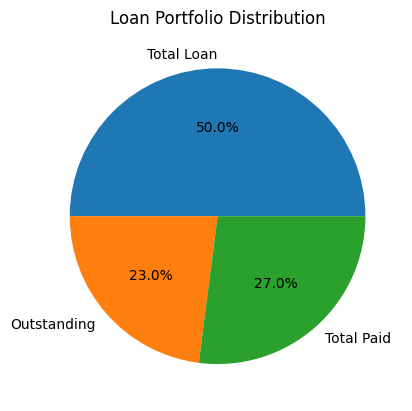

In [16]:
# 11. What is the total loan portfolio size?
loan_amount = loan['loan_amount'].sum()
outstanding_amount = loan['outstanding_amount'].sum()
total_paid_amount = loan['total_paid_amount'].sum()

values = [loan_amount, outstanding_amount, total_paid_amount]
labels = ['Total Loan', 'Outstanding', 'Total Paid']


plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Loan Portfolio Distribution")
plt.show()

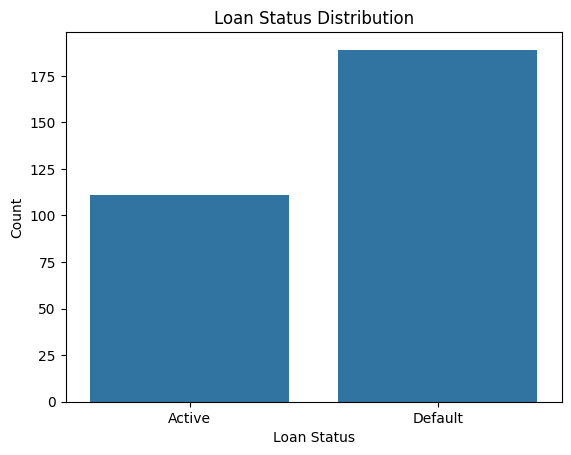

In [17]:
# 12. Countplot: Loan status distribution
sns.countplot(x='loan_status', data=loan)

plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.title("Loan Status Distribution")
plt.show()
